# Importing Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.transforms as mtransforms

import numpy as np
import scipy as sc
import seaborn as sns
import itertools
import math

!pip install pyproj
!pip install adjustText
!pip install scikit-learn

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter

from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import linregress
from scipy.stats import shapiro, ks_2samp, levene, ttest_ind, mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from pyproj import Transformer

from adjustText import adjust_text

# Calling in data

In [3]:
df = pd.read_csv("AvulsionAngles.csv")
df2 = pd.read_csv("Profiles.csv")
df3 = pd.read_csv("Fan Widths.csv")
df4 = pd.read_csv("Fan Morphometrics.csv")

# Defining fan groups

In [23]:
FAN_GROUPS = {
    "Subgroup 1a": ["Ili", "Abrisham", "Niger"],
    "Subgroup 1b": ["Saskatchewan", "Shire", "Okavango"],
    "Subgroup 2a": ["Canning", "Karnali", "Kosi", "Manas"],
    "Subgroup 2b": ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]
}

def assign_group(fan_name):
    for group, fans in FAN_GROUPS.items():
        if fan_name in fans:
            return group
    return "Unknown"

df5 = pd.DataFrame({"Fan": df4["Fan"].unique()})
df5["Group"] = df5["Fan"].apply(assign_group)

# 2. Computing C_apex (3 km upstream confinement loss)
conf_table = []

for fan_name in df2["Fan"].unique():
    sub = df2[df2["Fan"] == fan_name].sort_values("Distance").copy()
    
    # Find apex
    apex_mask = sub["Apex"].astype(str).str.lower().isin(["yes", "apex"])
    if not apex_mask.any():
        continue
    
    # Get first occurrence of apex
    apex_idx = sub[apex_mask].index[0]
    apex_dist = sub.loc[apex_idx, "Distance"]

    # 3 km upstream window 
    pre_apex = sub[
        (sub["Distance"] < apex_dist) & 
        (sub["Distance"] >= apex_dist - 3)
    ]

    if not pre_apex.empty:
        mean_topo = pre_apex["Mean Elevation"].mean()
        mean_river = pre_apex["River Elevation"].mean()
        conf_loss = mean_topo - mean_river  # C_apex calculation

        conf_table.append({
            "Fan": fan_name,
            "C_apex": conf_loss
        })

conf_df = pd.DataFrame(conf_table)

# 3. Adding TO df5
df5["C_apex"] = df5["Fan"].map(
    conf_df.set_index("Fan")["C_apex"]
)

print("--- Final df5 Summary ---")
print(df5[["Fan", "Group", "C_apex"]].head())
print("\nMissing C_apex values:", df5["C_apex"].isna().sum())

--- Final df5 Summary ---
        Fan        Group      C_apex
0  Abrisham  Subgroup 1a   17.216634
1   Canning  Subgroup 2a   17.870838
2     Cusay  Subgroup 2b   50.391760
3       Ili  Subgroup 1a    5.148993
4   Karnali  Subgroup 2a  173.900809

Missing C_apex values: 0


In [25]:
# Compute drainage & fan gradients

def slope_deg_from_dzdx(dz_m, dx_km):
    if dx_km <= 0 or np.isnan(dz_m):
        return np.nan
    return np.degrees(np.arctan(dz_m / (dx_km * 1000.0)))

def bulk_segment_slope_deg(dist_km, elev_m):
    if len(dist_km) < 2:
        return np.nan
    dz = elev_m.iloc[0] - elev_m.iloc[-1]
    dx = dist_km.iloc[-1] - dist_km.iloc[0]
    return slope_deg_from_dzdx(np.abs(dz), dx)

gradient_table = []

for fan_name in df2["Fan"].unique():
    sub = (
        df2[df2["Fan"] == fan_name]
        .sort_values("Distance")
        .reset_index(drop=True)
    )

    sub = sub.loc[~sub["Distance"].duplicated()].reset_index(drop=True)

    apex_idx_list = sub.index[sub["Apex"] == "Apex"].tolist()
    if not apex_idx_list:
        continue
    apex_idx = apex_idx_list[0]

    dr = sub.iloc[:apex_idx + 1]
    fn = sub.iloc[apex_idx:]

    drainage_deg = bulk_segment_slope_deg(dr["Distance"], dr["River Elevation"])
    fan_deg = bulk_segment_slope_deg(fn["Distance"], fn["River Elevation"])

    gradient_table.append({
        "Fan": fan_name,
        "Drainage Gradient (°)": drainage_deg,
        "Fan Gradient (°)": fan_deg,
        "Gradient Ratio (Drainage/Fan)": (
            drainage_deg / fan_deg
            if pd.notna(drainage_deg) and pd.notna(fan_deg) and fan_deg != 0
            else np.nan
        )
    })

gradient_df = pd.DataFrame(gradient_table)

gradient_df = gradient_df.set_index("Fan")
df5 = df5.set_index("Fan")

df5.loc[:, gradient_df.columns] = gradient_df

df5 = df5.reset_index()

print(df5[["Fan", "Drainage Gradient (°)", "Fan Gradient (°)", "Gradient Ratio (Drainage/Fan)"]])

                 Fan  Drainage Gradient (°)  Fan Gradient (°)  \
0           Abrisham               0.062521          0.031414   
1            Canning               0.178509          0.160389   
2              Cusay               3.096812          0.161223   
3                Ili               0.019473          0.010727   
4            Karnali               0.087780          0.055788   
5               Kosi               0.348264          0.017595   
6              Manas               0.255051          0.048938   
7              Niger               0.004396          0.002472   
8          Nomhon He               0.723286          0.506005   
9           Okavango               0.010337          0.009725   
10  Rud-i-Shur Tabas               0.581335          0.428419   
11      Saskatchewan               0.010743          0.006671   
12             Shire               0.020578          0.015221   

    Gradient Ratio (Drainage/Fan)  
0                        1.990207  
1                

# Fig. S5e: Change in channel width v. Confinement loss

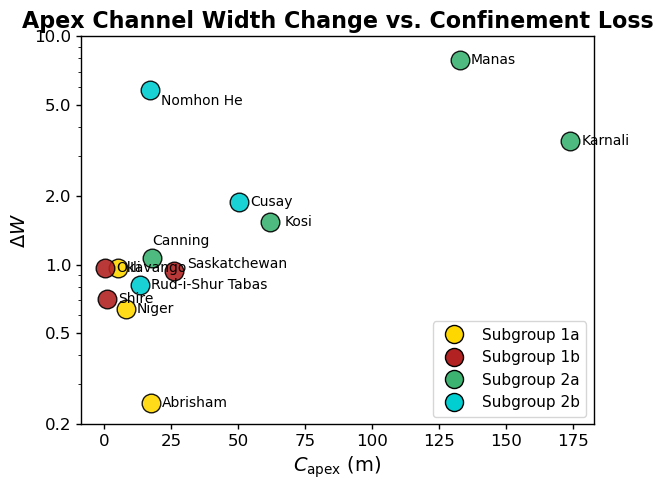

In [26]:
FAN_GROUPS = {
    "Subgroup 1a": ["Ili", "Abrisham", "Niger"],
    "Subgroup 1b": ["Saskatchewan", "Shire", "Okavango"],
    "Subgroup 2a": ["Canning", "Karnali", "Kosi", "Manas"],
    "Subgroup 2b": ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]
}

GROUP_COLORS = {
    "Subgroup 1a": "#FFD700",
    "Subgroup 1b": "#B22222",
    "Subgroup 2a": "#3CB371",
    "Subgroup 2b": "#00CED1"
}

def assign_group(fan_name):
    for group, fans in FAN_GROUPS.items():
        if fan_name in fans:
            return group
    return "Unknown"

# Initialize df5 from unique fans
df5 = pd.DataFrame({"Fan": df4["Fan"].unique()})
df5["Group"] = df5["Fan"].apply(assign_group)

# Compute C_apex from df2 ---
conf_table = []
for fan_name in df2["Fan"].unique():
    sub = df2[df2["Fan"] == fan_name].sort_values("Distance").copy()
    apex_mask = sub["Apex"].astype(str).str.lower().isin(["yes", "apex"])
    if not apex_mask.any(): continue
    apex_dist = sub.loc[sub[apex_mask].index[0], "Distance"]
    pre_apex = sub[(sub["Distance"] < apex_dist) & (sub["Distance"] >= apex_dist - 3)]
    if not pre_apex.empty:
        conf_table.append({
            "Fan": fan_name, 
            "C_apex": pre_apex["Mean Elevation"].mean() - pre_apex["River Elevation"].mean()
        })

df5 = df5.merge(pd.DataFrame(conf_table), on="Fan", how="left")

# Compute width ratio from df3
drain_cols = ['Drainage10', 'Drainage8', 'Drainage6', 'Drainage4', 'Drainage2']
fan_cols = ['Fan2', 'Fan4', 'Fan6', 'Fan8', 'Fan10']
df3['Drainage_Mean'] = df3[drain_cols].mean(axis=1)
df3['Fan_Mean'] = df3[fan_cols].mean(axis=1)
df5 = df5.merge(df3[['Fan', 'Fan_Mean', 'Drainage_Mean']], on="Fan", how="left")
df5['W_ratio'] = df5['Fan_Mean'] / df5['Drainage_Mean']

# Plotting
fig, ax = plt.subplots(figsize=(6.5, 5))

# Manual offsets
manual_offsets = {
    "Kosi": {"px": 10, "py": 0},
    "Canning": {"px": 0, "py": 12},
    "Nomhon He": {"px": 8, "py": -8},
    "Saskatchewan": {"px": 10, "py": 5}
}

# Plot points using the specific GROUP_COLORS
for g, col in GROUP_COLORS.items():
    sub = df5[df5["Group"] == g]
    if sub.empty: continue
    ax.scatter(
        sub["C_apex"], sub["W_ratio"], 
        s=180, color=col, edgecolor="black", 
        linewidth=1.0, label=g, zorder=3, alpha=0.9
    )

# Labels
for _, row in df5.iterrows():
    if pd.isna(row["C_apex"]) or pd.isna(row["W_ratio"]): continue
    name = row["Fan"]
    off = manual_offsets.get(name, {"px": 8, "py": 0})
    px, py = off["px"], off["py"]
    h_align = 'left' if px >= 0 else 'right'
    
    ax.text(
        row["C_apex"], row["W_ratio"], name, fontsize=10, 
        ha=h_align, va="center", zorder=5,
        transform=mtransforms.offset_copy(ax.transData, fig=fig, x=px, y=py, units='points')
    )

# Axes & formatting
ax.set_title("Apex Channel Width Change vs. Confinement Loss", fontsize=16, fontweight='bold')
ax.set_xlabel(r"$C_{\mathrm{apex}}$ (m)", fontsize=14)
ax.set_ylabel(r"$\Delta W$", fontsize=14)

ax.set_yscale('log')
ax.set_ylim(0.2, 10)
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_yticks([0.2, 0.5, 1, 2, 5, 10])

for spine in ax.spines.values():
    spine.set_linewidth(1.0)
ax.tick_params(axis="both", labelsize=12, width=1.0)
ax.grid(False)

# Legend
legend_elements = [
    mlines.Line2D([0], [0], marker='o', color='white', markerfacecolor=GROUP_COLORS[g],
                  linestyle='None', markersize=13, markeredgecolor='black', 
                  markeredgewidth=1.0, label=g)
    for g in GROUP_COLORS.keys() if g in df5["Group"].unique()
]
ax.legend(handles=legend_elements, loc="lower right", frameon=True, fontsize=11)

plt.tight_layout()
plt.show()

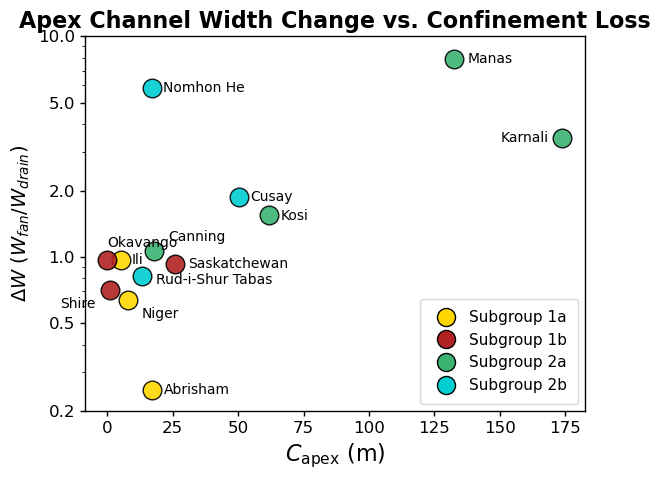

In [27]:
# Manuel offsets
manual_offsets = {
    "Manas": {"px": 10, "py": 0},
    "Niger": {"px": 10, "py": -10},
    "Shire": {"px": -10, "py": -10}, 
    "Rud-i-Shur Tabas": {"px": 10, "py": -3},
    "Saskatchewan": {"px": 10, "py": 0},
    "Okavango": {"px": 0, "py": 12},
    "Canning": {"px": 10, "py": 10},
    "Ili": {"px": 8, "py": 0},
    "Karnali": {"px": -10, "py": 0}

}

fig, ax = plt.subplots(figsize=(6.5, 5))

# Scatter points
for g, col in GROUP_COLORS.items():
    sub = df5[df5["Group"] == g]
    if sub.empty: continue
    ax.scatter(
        sub["C_apex"], sub["W_ratio"], 
        s=180, color=col, edgecolor="black", 
        linewidth=1.0, zorder=3, alpha=0.9
    )

# Labeling
for _, row in df5.iterrows():
    if pd.isna(row["C_apex"]) or pd.isna(row["W_ratio"]):
        continue
    
    name = row["Fan"]
    off = manual_offsets.get(name, {"px": 8, "py": 0})
    px, py = off["px"], off["py"]
    
    h_align = 'left' if px >= 0 else 'right'
        
    ax.text(
        row["C_apex"], 
        row["W_ratio"], 
        name, 
        fontsize=10, 
        ha=h_align, 
        va="center",
        transform=mtransforms.offset_copy(ax.transData, fig=fig, x=px, y=py, units='points'),
        zorder=5
    )

# Formatting & axis
ax.set_title(r"Apex Channel Width Change vs. Confinement Loss", fontsize=16, fontweight='bold')
ax.set_xlabel(r"$C_{\mathrm{apex}}$ (m)", fontsize=16)
ax.set_ylabel(r"$\Delta W$ ($W_{fan} / W_{drain}$)", fontsize=14)

ax.set_yscale('log')
ax.set_ylim(0.2, 10) 

ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_yticks([0.2, 0.5, 1, 2, 5, 10])

for spine in ax.spines.values():
    spine.set_linewidth(1.0)
ax.tick_params(axis="both", labelsize=12, width=1.0)
ax.grid(False)

# Legend
legend_elements = [
    mlines.Line2D([0], [0], marker='o', color='white', markerfacecolor=GROUP_COLORS[g],
                  linestyle='None', markersize=13, 
                  markeredgecolor='black', markeredgewidth=1.0, label=g)
    for g in GROUP_COLORS.keys() if g in df5["Group"].unique()
]

ax.legend(
    handles=legend_elements, 
    loc="lower right", 
    frameon=True, 
    fontsize=11,
    handletextpad=0.5,
    borderpad=0.7
)

plt.subplots_adjust(left=0.15, right=0.92, top=0.90, bottom=0.15)

plt.show()

# Fig. S6: Correlation Matrix

In [28]:
# Compute Fan Channel Length (apex→toe) & Sinuosity

def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance (m) between two lat/lon points."""
    R = 6371000  # meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Apex and toe coordinates for straight-line length
apex_coords = {
    "Abrisham": (35.61570558, 56.2550051),
    "Canning": (69.851, -146.461),
    "Cusay": (6.69162445, -71.84111181),
    "Ili": (44.8169747, 76.2228272),
    "Karnali": (28.610688, 81.2744661),
    "Kosi": (26.53, 86.938),
    "Manas": (26.78284555, 90.95510889),
    "Niger": (14.13861504, -5.02443996),
    "Nomhon He": (36.209, 96.385),
    "Okavango": (-18.858, 22.382),
    "Rud-i-Shur Tabas": (32.69999266, 60.54639206),
    "Saskatchewan": (53.70749938, -103.22863607),
    "Shire": (-16.2056, 34.9333)
}

toe_coords = {
    "Abrisham": (35.4077960, 55.9442017),
    "Canning": (70.0776829, -145.8115939),
    "Cusay": (6.70164919, -71.1415035),
    "Ili": (46.5798760, 75.4267887),
    "Karnali": (28.272984, 81.0855275),
    "Kosi": (25.4124270, 87.2551879),
    "Manas": (26.2501896, 90.817693),
    "Niger": (15.29728494, -3.97095891),
    "Nomhon He": (36.5690979, 96.467773),
    "Okavango": (-19.2357331, 23.9332574),
    "Rud-i-Shur Tabas": (32.6369173, 60.8883672),
    "Saskatchewan": (54.036199, -102.520279),
    "Shire": (-16.5488535, 35.12352637)
}

# Compute fan channel length (apex→toe) & sinuosity
fan_channel_lengths = []
fan_lengths = []
sinuosities = []

for fan_name in df5["Fan"]:
    fan_df = df2[df2["Fan"] == fan_name].copy().sort_values("Distance").reset_index(drop=True)

    if fan_df.empty:
        fan_channel_lengths.append(np.nan)
        fan_lengths.append(np.nan)
        sinuosities.append(np.nan)
        continue

    # Identify apex index
    apex_idx_list = fan_df.index[fan_df["Apex"] == "Apex"].tolist()
    if not apex_idx_list:
        fan_channel_lengths.append(np.nan)
        fan_lengths.append(np.nan)
        sinuosities.append(np.nan)
        continue
    apex_idx = apex_idx_list[0]

    # Trim to only downstream of apex (apex→end)
    fan_df = fan_df.iloc[apex_idx:].reset_index(drop=True)

    # Channel length (summed haversine distances)
    if {"Latitude", "Longitude"}.issubset(fan_df.columns):
        segment_lengths = []
        for i in range(1, len(fan_df)):
            lat1, lon1 = fan_df.loc[i - 1, ["Latitude", "Longitude"]]
            lat2, lon2 = fan_df.loc[i, ["Latitude", "Longitude"]]
            segment_lengths.append(haversine(lat1, lon1, lat2, lon2))
        fan_channel_len_km = np.nansum(segment_lengths) / 1000.0
    else:
        # fallback: distance difference (in km)
        dist_apex = fan_df["Distance"].iloc[0]
        dist_end = fan_df["Distance"].max()
        fan_channel_len_km = abs(dist_end - dist_apex)

    # Straight-line fan length (apex→toe)
    if fan_name in apex_coords and fan_name in toe_coords:
        lat1, lon1 = apex_coords[fan_name]
        lat2, lon2 = toe_coords[fan_name]
        fan_len_km = haversine(lat1, lon1, lat2, lon2) / 1000.0
    else:
        fan_len_km = np.nan

    # Sinuosity
    sinuosity_val = fan_channel_len_km / fan_len_km if fan_len_km > 0 else np.nan

    fan_channel_lengths.append(fan_channel_len_km)
    fan_lengths.append(fan_len_km)
    sinuosities.append(sinuosity_val)


# Add to df5
df5["Fan channel length"] = np.round(fan_channel_lengths, 2)
df5["Fan length"] = np.round(fan_lengths, 2)
df5["Sinuosity"] = np.round(sinuosities, 2)

df5["Check"] = np.where(df5["Sinuosity"] < 1, "⚠️ verify distances", "")
print(df5[["Fan", "Fan channel length", "Fan length", "Sinuosity", "Check"]])

                 Fan  Fan channel length  Fan length  Sinuosity Check
0           Abrisham                  45       36.41       1.24      
1            Canning                  39       35.32       1.10      
2              Cusay                 113       77.27       1.46      
3                Ili                 266      205.54       1.29      
4            Karnali                  57       41.85       1.36      
5               Kosi                 270      128.25       2.11      
6              Manas                  80       60.79       1.32      
7              Niger                 370      171.57       2.16      
8          Nomhon He                  42       40.72       1.03      
9           Okavango                 269      168.37       1.60      
10  Rud-i-Shur Tabas                  36       32.77       1.10      
11      Saskatchewan                  73       59.10       1.24      
12             Shire                  72       43.23       1.67      


In [29]:
# Elevation changes (Drainage and Fan)

drainage_elev_changes = []
fan_elev_changes = []
total_elev_changes = []

for fan_name in df5['Fan']:
    fan_df = df2[df2['Fan'] == fan_name].copy().sort_values('Distance').reset_index(drop=True)
    if fan_df.empty:
        drainage_elev_changes.append(np.nan)
        fan_elev_changes.append(np.nan)
        total_elev_changes.append(np.nan)
        continue

    # Find apex row
    apex_idx = fan_df[fan_df['Apex'] == 'Apex'].index
    if len(apex_idx) == 0:
        drainage_elev_changes.append(np.nan)
        fan_elev_changes.append(np.nan)
        total_elev_changes.append(np.nan)
        continue
    apex_idx = apex_idx[0]

    # River elevations
    elev_start = fan_df.loc[0, 'River Elevation']
    elev_apex = fan_df.loc[apex_idx, 'River Elevation']
    elev_toe  = fan_df.loc[len(fan_df) - 1, 'River Elevation']

    # Elevation changes
    drainage_change = elev_start - elev_apex
    fan_change = elev_apex - elev_toe
    total_change = elev_start - elev_toe

    # Append results
    drainage_elev_changes.append(drainage_change)
    fan_elev_changes.append(fan_change)
    total_elev_changes.append(total_change)

# Add to df5
df5['Drainage elevation change'] = drainage_elev_changes
df5['Fan elevation change'] = fan_elev_changes
df5['Total elevation change'] = total_elev_changes

# Print check
print(df5[['Fan', 'Drainage elevation change', 'Fan elevation change', 'Total elevation change']])

                 Fan  Drainage elevation change  Fan elevation change  \
0           Abrisham                   49.10360             24.672600   
1            Canning                  149.54770            109.173546   
2              Cusay                 1839.47660            317.969000   
3                Ili                   52.00000             49.799600   
4            Karnali                  119.50000             55.500000   
5               Kosi                  820.58680             82.914100   
6              Manas                  378.37840             68.330730   
7              Niger                   15.50000             15.960400   
8          Nomhon He                  618.59500            370.931000   
9           Okavango                   52.50000             45.657104   
10  Rud-i-Shur Tabas                  233.37100            269.188400   
11      Saskatchewan                    1.50000              8.500000   
12             Shire                   19.75394    

In [30]:
# Number of Avulsion & Crevasse Nodes per Fan

# Count total nodes per fan
total_nodes = df.groupby('Fan').size()

# Count Crevasse and Avulsion nodes
crevasse_nodes = df[df['Crevasse'] == 'Yes'].groupby('Fan').size()
avulsion_nodes = df[df['Crevasse'] == 'No'].groupby('Fan').size()

# Map into df5
df5['Total nodes'] = df5['Fan'].map(total_nodes)
df5['Crevasse nodes'] = df5['Fan'].map(crevasse_nodes)
df5['Avulsion nodes'] = df5['Fan'].map(avulsion_nodes)

# Fill missing values with 0
df5[['Total nodes', 'Crevasse nodes', 'Avulsion nodes']] = (
    df5[['Total nodes', 'Crevasse nodes', 'Avulsion nodes']].fillna(0).astype(int)
)

# Compute Avulsion:Crevasse ratio
df5['Avulsion:Crevasse ratio'] = df5.apply(
    lambda row: row['Avulsion nodes'] / row['Crevasse nodes']
    if row['Crevasse nodes'] > 0 else np.nan,
    axis=1
)

# Print
print(df5[['Fan', 'Total nodes', 'Avulsion nodes', 'Crevasse nodes', 'Avulsion:Crevasse ratio']])


                 Fan  Total nodes  Avulsion nodes  Crevasse nodes  \
0           Abrisham          109              37              72   
1            Canning            4               4               0   
2              Cusay           14               7               7   
3                Ili          173             108              65   
4            Karnali            1               1               0   
5               Kosi            4               4               0   
6              Manas            3               3               0   
7              Niger           90              59              31   
8          Nomhon He           45              36               9   
9           Okavango           63               8              55   
10  Rud-i-Shur Tabas           21              19               2   
11      Saskatchewan           85              50              35   
12             Shire           56              27              29   

    Avulsion:Crevasse ratio  
0  

In [31]:
angle_results = []

for fan_name in df5["Fan"]:
    # Get the profile for this fan to find the Apex distance
    fan_profile = df2[df2["Fan"] == fan_name].copy()
    apex_row = fan_profile[fan_profile["Apex"].astype(str).str.lower().isin(["yes", "apex"])]
    
    # Get the avulsion angles for this fan
    fan_angles = df[df["Fan"] == fan_name].copy()
    
    if not fan_angles.empty and not apex_row.empty:
        apex_dist_val = apex_row["Distance"].iloc[0]
        
        # Mean Avulsion Angle (All nodes in df)
        mean_total = fan_angles["Angle"].mean()
                    
        # Checking available columns in 'df' 
        if "Distance" in fan_angles.columns:
            mean_apex = fan_angles[np.isclose(fan_angles["Distance"], apex_dist_val, atol=0.1)]["Angle"].mean()
            mean_downfan = fan_angles[fan_angles["Distance"] > apex_dist_val]["Angle"].mean()
        elif "Apex" in fan_angles.columns:
            # Fallback if 'df' uses a 'Yes/No' column for Apex instead of numeric distance
            mean_apex = fan_angles[fan_angles["Apex"].astype(str).str.lower().isin(["yes", "apex"])]["Angle"].mean()
            mean_downfan = fan_angles[~fan_angles["Apex"].astype(str).str.lower().isin(["yes", "apex"])]["Angle"].mean()
        else:
            mean_apex = np.nan
            mean_downfan = np.nan
    else:
        mean_total = mean_apex = mean_downfan = np.nan

    angle_results.append({
        "Fan": fan_name,
        "Mean avulsion angle": mean_total,
        "Mean apex angle": mean_apex,
        "Mean downfan angle": mean_downfan
    })

angle_df = pd.DataFrame(angle_results)

# Update df5 using the standard mapping method you used for C_apex
df5["Mean avulsion angle"] = df5["Fan"].map(angle_df.set_index("Fan")["Mean avulsion angle"])
df5["Mean apex angle"] = df5["Fan"].map(angle_df.set_index("Fan")["Mean apex angle"])
df5["Mean downfan angle"] = df5["Fan"].map(angle_df.set_index("Fan")["Mean downfan angle"])

print("--- Angle Calculation Check ---")
print(df5[["Fan", "Mean avulsion angle", "Mean apex angle", "Mean downfan angle"]].head())

--- Angle Calculation Check ---
        Fan  Mean avulsion angle  Mean apex angle  Mean downfan angle
0  Abrisham            70.486239            47.75           71.352381
1   Canning            33.750000            37.00           32.666667
2     Cusay            69.071429            36.50           74.500000
3       Ili            71.849711            50.00           72.366864
4   Karnali            41.000000            41.00                 NaN


In [32]:
gradient_table = []

for fan_name in df2["Fan"].unique():
    sub = df2[df2["Fan"] == fan_name].sort_values("Distance").drop_duplicates("Distance").reset_index(drop=True)
    
    apex_idx_list = sub.index[sub["Apex"].astype(str).str.lower().isin(["yes", "apex"])].tolist()
    if not apex_idx_list:
        continue
    apex_idx = apex_idx_list[0]

    dr = sub.iloc[:apex_idx + 1]
    fn = sub.iloc[apex_idx:]

    # Use bulk_segment_slope_deg function
    drainage_deg = bulk_segment_slope_deg(dr["Distance"], dr["River Elevation"])
    fan_deg = bulk_segment_slope_deg(fn["Distance"], fn["River Elevation"])

    gradient_table.append({
        "Fan": fan_name,
        "Drainage Gradient (°)": drainage_deg,
        "Fan Gradient (°)": fan_deg,
        "Gradient Ratio (Drainage/Fan)": (drainage_deg / fan_deg if fan_deg != 0 else np.nan)
    })

# Convert to DF and Map into df5
grad_df = pd.DataFrame(gradient_table).set_index("Fan")
for col in grad_df.columns:
    df5[col] = df5["Fan"].map(grad_df[col])

print("Confirmed Gradient Columns:", [c for c in df5.columns if "Gradient" in c])

Confirmed Gradient Columns: ['Drainage Gradient (°)', 'Fan Gradient (°)', 'Gradient Ratio (Drainage/Fan)']


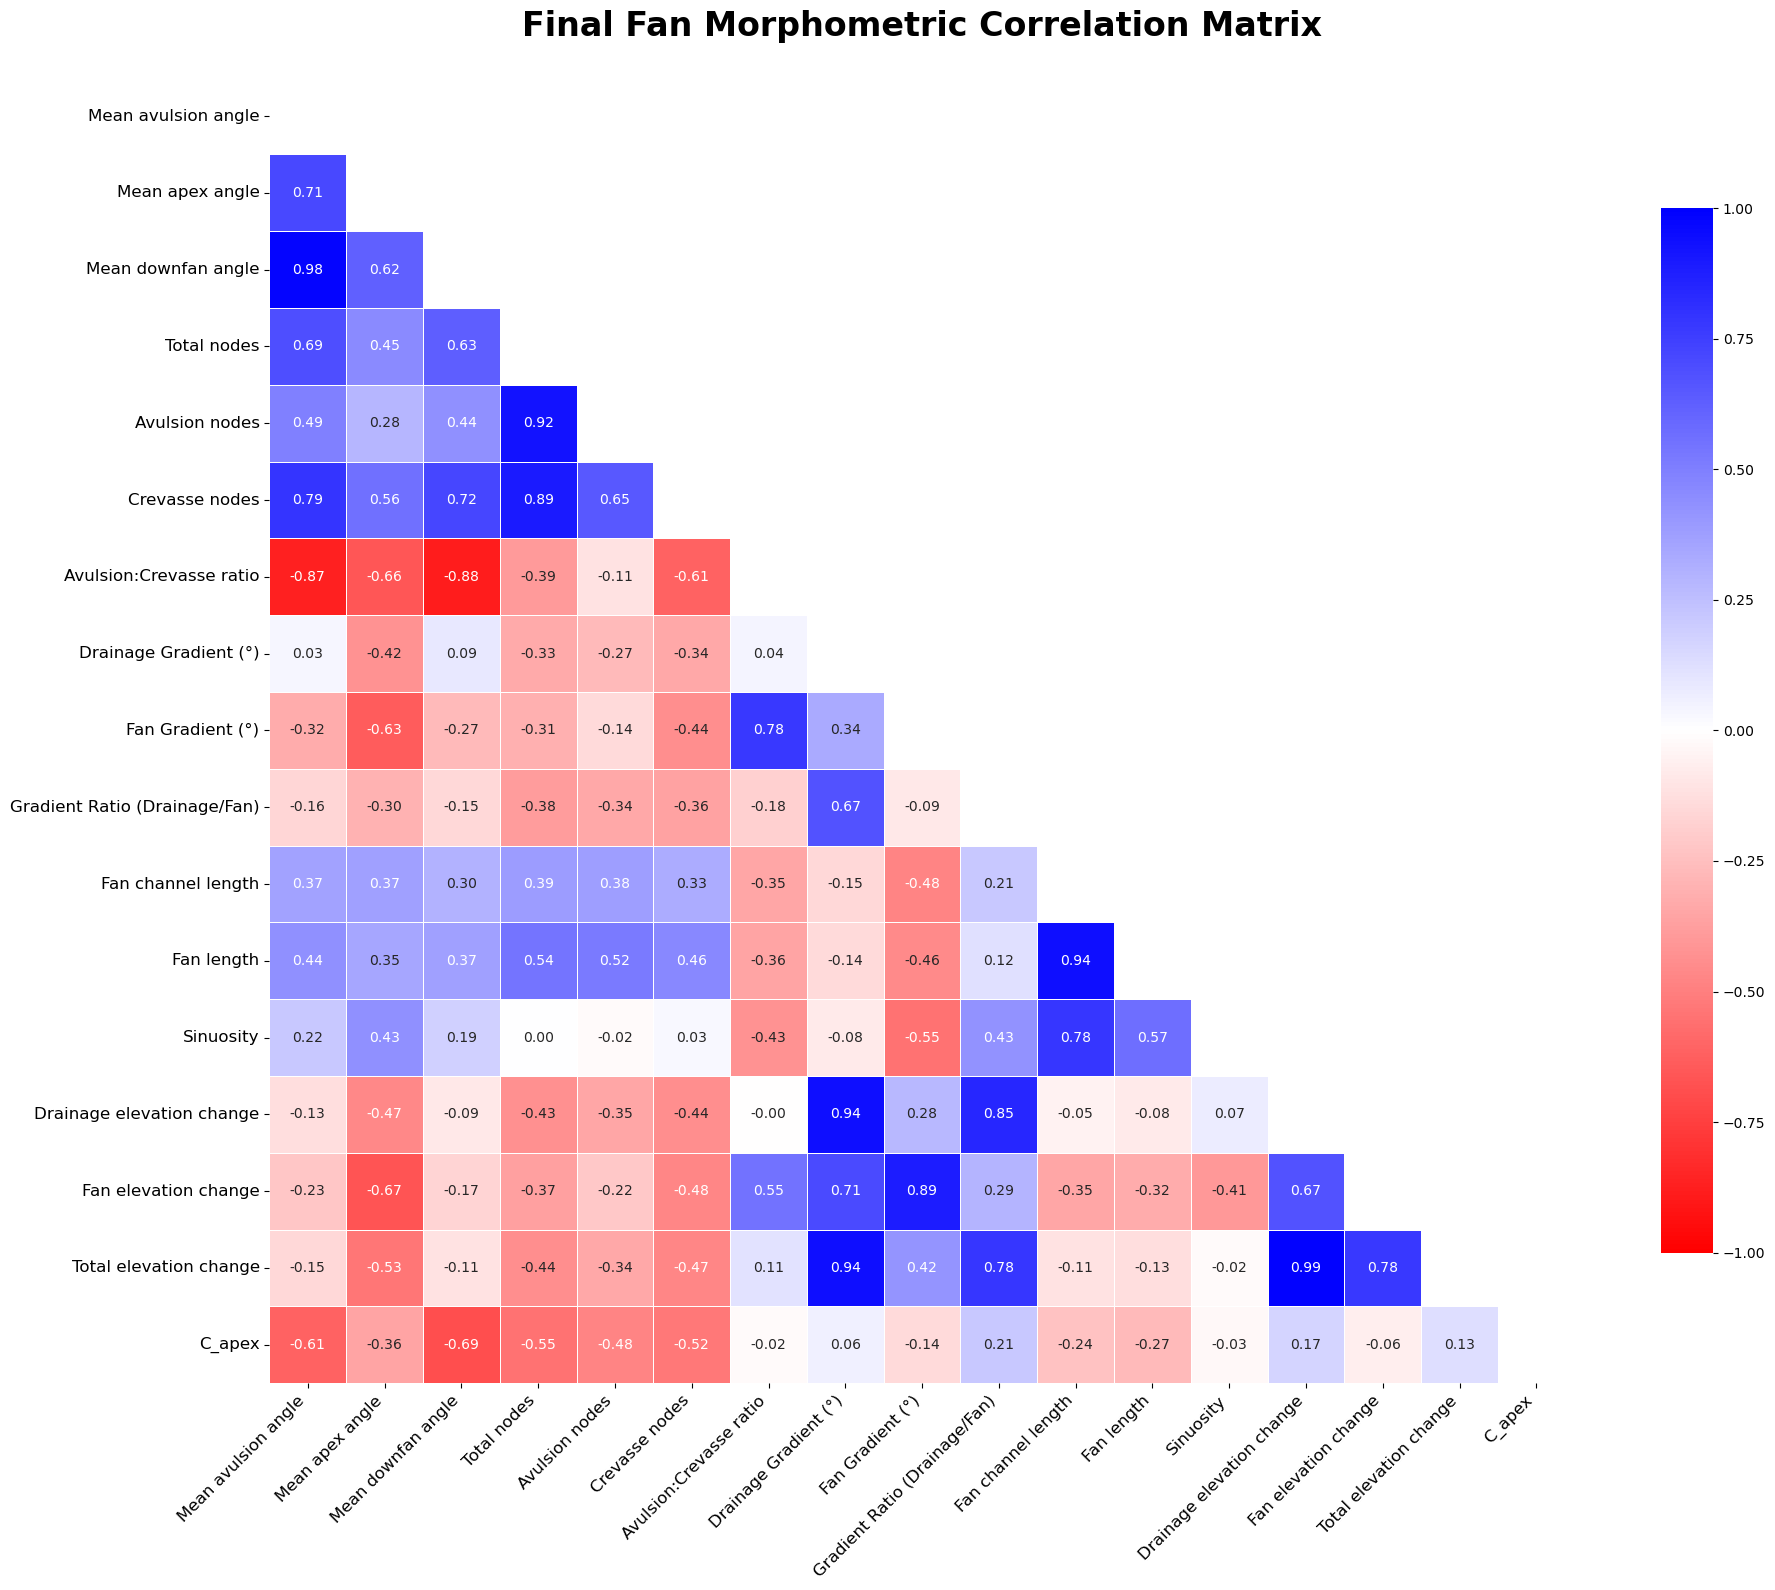

In [33]:
cols = [
    'Mean avulsion angle', 'Mean apex angle', 'Mean downfan angle',
    'Total nodes', 'Avulsion nodes', 'Crevasse nodes', 'Avulsion:Crevasse ratio',
    'Drainage Gradient (°)', 'Fan Gradient (°)', 'Gradient Ratio (Drainage/Fan)',
    'Fan channel length', 'Fan length', 'Sinuosity',
    'Drainage elevation change', 'Fan elevation change', 'Total elevation change',
    'C_apex'
]

df_corr = df5[cols].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)
corr_matrix = df_corr.corr(min_periods=1)

plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="bwr_r", 
    vmin=-1, vmax=1, center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)

plt.title("Final Fan Morphometric Correlation Matrix", fontsize=24, fontweight='bold', pad=30)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# Fig. 1f: Dendrogram

Variables used: ['Mean avulsion angle', 'Mean apex angle', 'Mean downfan angle', 'Fan Gradient (°)', 'Gradient Ratio (Drainage/Fan)', 'Total nodes', 'Avulsion:Crevasse ratio']

=== Missing Values per Variable ===
Mean avulsion angle              0
Mean apex angle                  0
Mean downfan angle               1
Fan Gradient (°)                 0
Gradient Ratio (Drainage/Fan)    0
Total nodes                      0
Avulsion:Crevasse ratio          4
dtype: int64

=== Fans that have at least one NaN ===
    Fan
Canning
Karnali
   Kosi
  Manas

Total fans in df5: 13
Fans with complete data: 9
Fans with missing data (will be kept with imputation): 4


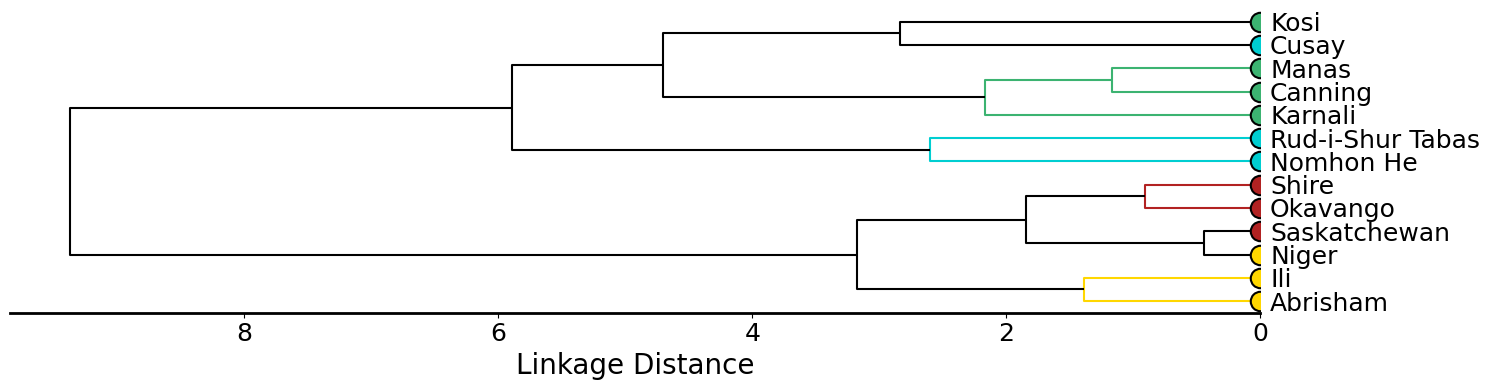

In [34]:
#  7 Variables
variables = [
    'Mean avulsion angle',
    'Mean apex angle',
    'Mean downfan angle',
    'Fan Gradient (°)',
    'Gradient Ratio (Drainage/Fan)',
    'Total nodes',
    'Avulsion:Crevasse ratio'
]

print("Variables used:", variables)

# Prepare data
numeric_data = df5[variables].copy()

# Show missing values
print("\n=== Missing Values per Variable ===")
print(numeric_data.isna().sum())

print("\n=== Fans that have at least one NaN ===")
missing_mask = numeric_data.isna().any(axis=1)
print(df5[missing_mask][['Fan']].to_string(index=False))

print(f"\nTotal fans in df5: {len(df5)}")
print(f"Fans with complete data: {len(df5) - missing_mask.sum()}")
print(f"Fans with missing data (will be kept with imputation): {missing_mask.sum()}")

# Mean
numeric_data_clean = numeric_data.fillna(numeric_data.mean())

# Standardize
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_data_clean)

# Clustering
Z = linkage(numeric_scaled, method='ward')

fan_labels = df5['Fan'].values.tolist()
n_fans = len(fan_labels)

# Group Colors
group_colors = {
    'Ili': '#FFD700', 'Abrisham': '#FFD700', 'Niger': '#FFD700',
    'Nomhon He': '#00CED1', 'Cusay': '#00CED1', 'Rud-i-Shur Tabas': '#00CED1',
    'Manas': '#3CB371', 'Canning': '#3CB371', 'Karnali': '#3CB371', 'Kosi': '#3CB371',
    'Saskatchewan': '#B22222', 'Shire': '#B22222', 'Okavango': '#B22222'
}

# Leaf color function
def get_leaves(link_id):
    if link_id < n_fans:
        return [fan_labels[link_id]]
    left = int(Z[link_id - n_fans, 0])
    right = int(Z[link_id - n_fans, 1])
    return get_leaves(left) + get_leaves(right)

def link_color_func(link_id):
    leaves = get_leaves(link_id)
    colors = [group_colors.get(name, 'black') for name in leaves]
    if len(set(colors)) == 1:
        return colors[0]
    return 'black'

# Plot Dendogram
fig, ax = plt.subplots(figsize=(15, 4))

ddata = dendrogram(
    Z,
    labels=fan_labels,
    orientation='left',
    leaf_font_size=20,
    link_color_func=link_color_func,
    color_threshold=0,
    above_threshold_color='black'
)

# Thick lines
for line in ax.get_lines():
    line.set_linewidth(12)

ax.set_xlabel('Linkage Distance', fontsize=20)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

for s in ['top', 'right', 'left']:
    ax.spines[s].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_linewidth(2)

# Colored leaf dots
yticks = ax.get_yticks()
ylabels = ddata['ivl']
for y, label in zip(yticks, ylabels):
    color = group_colors.get(label, 'black')
    ax.plot(0, y, 'o', markersize=14, 
            markerfacecolor=color,
            markeredgecolor='black', 
            markeredgewidth=1.5, 
            zorder=10)

plt.title("", fontsize=15, pad=25)
plt.tight_layout()
plt.show()

#  Supporting Fig. 7: PCA

=== Missing Values (V2) ===
Fan Gradient (°)                 0
Gradient Ratio (Drainage/Fan)    0
C_apex                           0
Mean avulsion angle              0
Mean apex angle                  0
Avulsion:Crevasse ratio          4
dtype: int64

=== PCA V2 Explained Variance ===
PC1: 0.4771 (cum 0.4771)
PC2: 0.2686 (cum 0.7457)
PC3: 0.1475 (cum 0.8932)
PC4: 0.0427 (cum 0.9359)
PC5: 0.0403 (cum 0.9762)
PC6: 0.0238 (cum 1.0000)

=== PC1 Loadings ===
Mean apex angle                  0.546
Mean avulsion angle              0.484
Avulsion:Crevasse ratio         -0.461
Fan Gradient (°)                -0.431
C_apex                          -0.241
Gradient Ratio (Drainage/Fan)   -0.104
Name: PC1, dtype: float64

=== PC2 Loadings ===
C_apex                           0.595
Gradient Ratio (Drainage/Fan)    0.466
Fan Gradient (°)                -0.449
Avulsion:Crevasse ratio         -0.377
Mean avulsion angle             -0.284
Mean apex angle                 -0.069
Name: PC2, dtype: float64


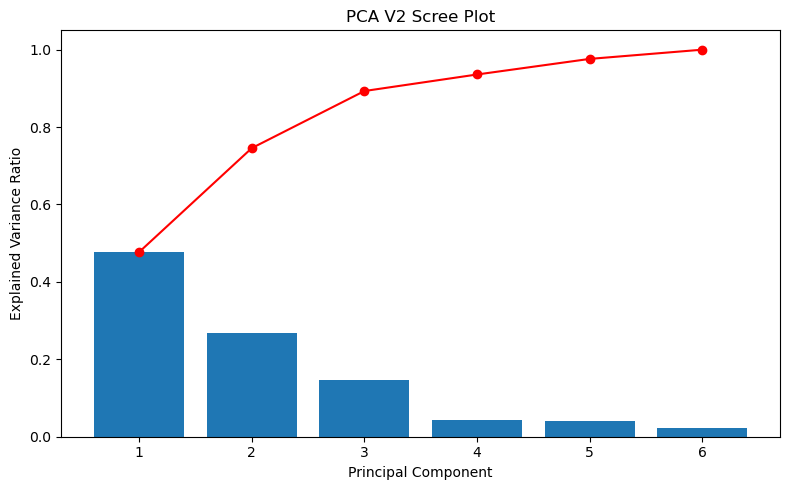

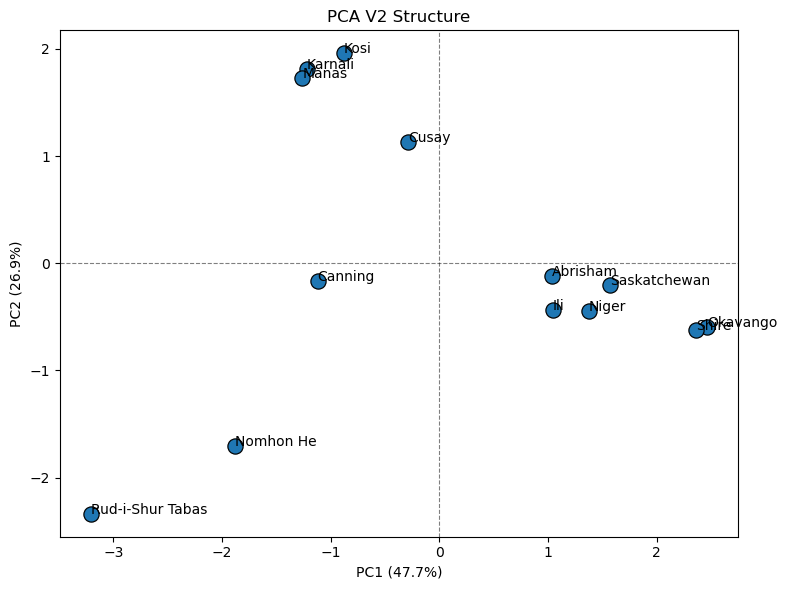

In [35]:
# Defining Variables
variables_v2 = [
    'Fan Gradient (°)',
    'Gradient Ratio (Drainage/Fan)',
    'C_apex',
    'Mean avulsion angle',
    'Mean apex angle',
    'Avulsion:Crevasse ratio'
]

# Building matrix
missing = [v for v in variables_v2 if v not in df5.columns]
if missing:
    raise ValueError(f"Missing columns in df5: {missing}")

X_v2 = df5[variables_v2].copy()

print("=== Missing Values (V2) ===")
print(X_v2.isna().sum())

# Mean imputation
X_v2_clean = X_v2.fillna(X_v2.mean())

# Standardize 
scaler_v2 = StandardScaler()
X_v2_scaled = scaler_v2.fit_transform(X_v2_clean)

# PCA
pca_v2 = PCA()
X_v2_pca = pca_v2.fit_transform(X_v2_scaled)

explained_var_v2 = pca_v2.explained_variance_ratio_
cumulative_var_v2 = np.cumsum(explained_var_v2)

print("\n=== PCA V2 Explained Variance ===")
for i in range(len(explained_var_v2)):
    print(f"PC{i+1}: {explained_var_v2[i]:.4f} (cum {cumulative_var_v2[i]:.4f})")

# Loadings (True contribution, not squared-only view)
loadings_v2 = pd.DataFrame(
    pca_v2.components_.T,
    columns=[f'PC{i+1}' for i in range(len(variables_v2))],
    index=variables_v2
)

print("\n=== PC1 Loadings ===")
print(loadings_v2['PC1'].sort_values(key=abs, ascending=False).round(3))

print("\n=== PC2 Loadings ===")
print(loadings_v2['PC2'].sort_values(key=abs, ascending=False).round(3))

# Scree Plot
plt.figure(figsize=(8,5))
plt.bar(range(1, len(explained_var_v2)+1), explained_var_v2)
plt.plot(range(1, len(explained_var_v2)+1), cumulative_var_v2, 'ro-')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA V2 Scree Plot")
plt.tight_layout()
plt.show()

# Score Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_v2_pca[:,0],
    y=X_v2_pca[:,1],
    s=120,
    edgecolor="black"
)

# Labels
for i, fan in enumerate(df5["Fan"]):
    plt.text(X_v2_pca[i,0], X_v2_pca[i,1], fan, fontsize=10)

plt.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
plt.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)

plt.xlabel(f"PC1 ({explained_var_v2[0]:.1%})")
plt.ylabel(f"PC2 ({explained_var_v2[1]:.1%})")
plt.title("PCA V2 Structure")

plt.tight_layout() 
plt.show()

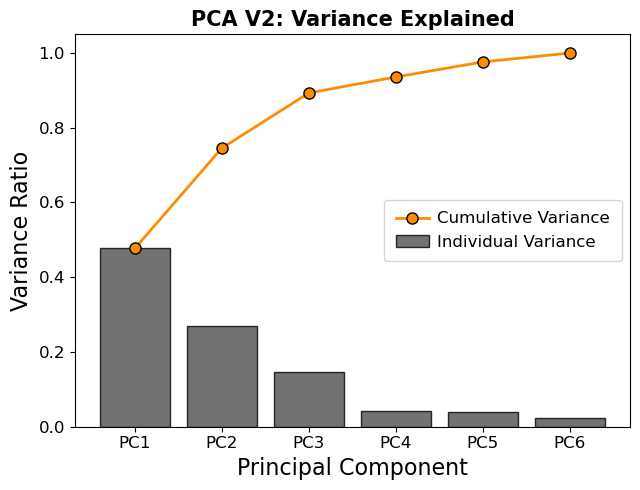

In [36]:
# Plot setup
fig, ax = plt.subplots(figsize=(6.5, 5))

pc_labels = [f"PC{i+1}" for i in range(len(explained_var_v2))]
x_range = range(1, len(explained_var_v2) + 1)

# Plotting
ax.bar(x_range, explained_var_v2, color="#4F4F4F", alpha=0.8, 
       edgecolor="black", label="Individual Variance", zorder=2)

ax.plot(x_range, cumulative_var_v2, marker='o', color="#FF8C00", 
        linewidth=2, markersize=8, markeredgecolor="black", 
        label="Cumulative Variance", zorder=3)

# Formatting
ax.set_title("PCA V2: Variance Explained", fontsize=15, fontweight='bold')
ax.set_xlabel("Principal Component", fontsize=16)
ax.set_ylabel("Variance Ratio", fontsize=16)

ax.set_xticks(x_range)
ax.set_xticklabels(pc_labels)

ax.tick_params(axis="both", labelsize=12)
ax.set_ylim(0, 1.05)
ax.grid(False)

# Legend
ax.legend(
    fontsize=12, 
    loc="center right", 
    frameon=True,
    handletextpad=0.5,
    borderpad=0.7
)

plt.tight_layout()
plt.show()

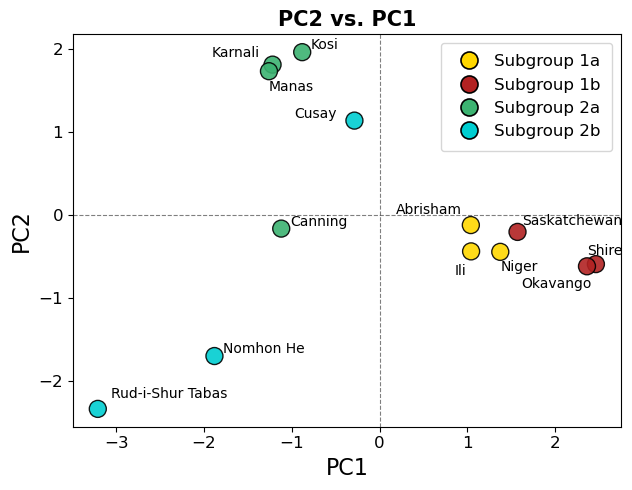

In [37]:
subgroup_1a_fans = ["Abrisham", "Ili", "Niger"]
subgroup_1b_fans = ["Okavango", "Saskatchewan", "Shire"]
subgroup_2a_fans = ["Canning", "Karnali", "Kosi", "Manas"]
subgroup_2b_fans = ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]

colors = {
    "Subgroup 1a": "#FFD700",
    "Subgroup 1b": "#B22222",
    "Subgroup 2a": "#3CB371",
    "Subgroup 2b": "#00CED1"
}

def assign_group(fan):
    if fan in subgroup_1a_fans: return "Subgroup 1a"
    if fan in subgroup_1b_fans: return "Subgroup 1b"
    if fan in subgroup_2a_fans: return "Subgroup 2a"
    if fan in subgroup_2b_fans: return "Subgroup 2b"
    return "Unknown"

df5["Group"] = df5["Fan"].apply(assign_group)

# Manual label offsets
manual_offsets_pca = {
    "Ili": (-0.05, -0.15),
    "Kosi": (0.1, 0),
    "Manas": (0, -0.1),
    "Karnali": (-0.15, 0.05),
    "Canning": (0.10, 0),

    "Okavango": (-0.05, -0.15),
    "Shire": (0, 0.1),
    "Saskatchewan": (0.05, 0.05),

    "Abrisham": (-0.10, 0.1),
    "Niger": (0, -.1),

    "Cusay": (-0.20, 0.00),
    "Nomhon He": (0.10, 0),
    "Rud-i-Shur Tabas": (0.15, 0.10)
}

default_offset = (0.12, 0.05)

# Create PCA Score Plot
fig, ax = plt.subplots(figsize=(6.5, 5))

ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5, zorder=1)
ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5, zorder=1)

sns.scatterplot(
    x=X_v2_pca[:, 0],
    y=X_v2_pca[:, 1],
    hue=df5["Group"],
    palette=colors,
    s=150,
    edgecolor="black",
    alpha=0.9,
    legend=False,
    zorder=3,
    ax=ax
)

# Labels
for i, fan in enumerate(df5["Fan"]):
    dx, dy = manual_offsets_pca.get(fan, default_offset)

    ax.text(
        X_v2_pca[i, 0] + dx,
        X_v2_pca[i, 1] + dy,
        fan,
        fontsize=10,
        ha="left" if dx >= 0 else "right",
        va="bottom" if dy >= 0 else "top",
        zorder=5
    )

# Formatting
ax.set_title("PC2 vs. PC1", fontsize=15, fontweight='bold')
ax.set_xlabel(f"PC1", fontsize=16)
ax.set_ylabel(f"PC2", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.grid(False)

# Legend
msize = np.sqrt(150)
legend_elements = [
    mlines.Line2D([0], [0], marker='o', color='white',
                  markerfacecolor=colors[g],
                  linestyle='None',
                  markersize=msize,
                  markeredgecolor='black',
                  markeredgewidth=1.2,
                  label=g)
    for g in ["Subgroup 1a", "Subgroup 1b", "Subgroup 2a", "Subgroup 2b"]
]

ax.legend(
    handles=legend_elements,
    fontsize=12,
    loc="best",
    frameon=True,
    handletextpad=0.5,
    borderpad=0.7
)

plt.tight_layout()
plt.show()